#1. PORTADA



## TAREA 1
## Análisis Exploratorio de Datos y Machine Learning sobre Riesgo Crediticio en Ecuador

**Maestría en Tecnologías de la Información**
Mención Transformación Digital e Innovación

**Módulo:** Big Data, Analytics & Data Scientist

**Estudiante:** Ramiro Iván Morales Pilaguano

**Docente:** Ing. Carlos Wladimir Carrillo Villavicencio MSc. TIC.

**Fecha:** Junio 2026

#2. Índice



1. Introducción
2. Carga de librerías
3. Lectura del dataset
4. Descripción del dataset
5. Limpieza y preparación de datos
6. Análisis exploratorio de datos (EDA)
7. Visualizaciones
8. Preparación para Machine Learning
9. Entrenamiento del modelo
10. Evaluación del modelo
11. Optimización básica
12. Conclusiones
13. Recomendaciones

#3. INTRODUCCIÓN

Las instituciones financieras utilizan modelos de análisis de datos para evaluar el riesgo asociado a la aprobación de créditos.

El objetivo de este proyecto es analizar un dataset de solicitudes de crédito en Ecuador para identificar patrones asociados a la aprobación o rechazo de créditos, mediante técnicas de limpieza de datos, análisis exploratorio, visualización y Machine Learning supervisado.

La variable objetivo seleccionada es:

**Estado_Credito**

- Aprobado
- Rechazado

Problema de negocio:

¿Es posible predecir si una solicitud de crédito será aprobada o rechazada utilizando información demográfica, laboral y financiera del solicitante?

#4. CARGA DE LIBRERÍAS

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV

sns.set_style("whitegrid")

#5. CARGA DEL DATASET

In [2]:
df = pd.read_csv("/content/Creditos_Ecuador.csv")

df.head()

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
0,44,27200,Santo Domingo,Hipotecada,2,Vehículo,B,14781,23.03,0.54,No,714,Rechazado
1,24,18891,Santo Domingo,Propia,25,Negocio,D,2930,11.83,0.16,No,631,Aprobado
2,50,8708,Ibarra,Hipotecada,33,Consumo,E,8774,19.09,1.01,Sí,554,Rechazado
3,56,70325,Portoviejo,Propia,25,Salud,A,5557,9.51,0.08,No,786,Aprobado
4,24,10879,Manta,Propia,6,Consumo,A,26782,12.48,2.46,No,767,Rechazado


#6. DESCRIPCIÓN DEL DATASET

In [3]:
df.shape

(60000, 13)

In [4]:
df.columns

Index(['Edad', 'Ingreso_Anual', 'Ciudad', 'Tipo_Vivienda', 'Años_Empleo',
       'Motivo_Credito', 'Calificacion_Credito', 'Monto_Credito',
       'Tasa_Interes', 'Porcentaje_Ingreso', 'Historial_Mora',
       'Score_Crediticio', 'Estado_Credito'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Edad                  60000 non-null  int64  
 1   Ingreso_Anual         60000 non-null  int64  
 2   Ciudad                60000 non-null  object 
 3   Tipo_Vivienda         60000 non-null  object 
 4   Años_Empleo           60000 non-null  int64  
 5   Motivo_Credito        60000 non-null  object 
 6   Calificacion_Credito  60000 non-null  object 
 7   Monto_Credito         60000 non-null  int64  
 8   Tasa_Interes          60000 non-null  float64
 9   Porcentaje_Ingreso    60000 non-null  float64
 10  Historial_Mora        60000 non-null  object 
 11  Score_Crediticio      60000 non-null  int64  
 12  Estado_Credito        60000 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 6.0+ MB


In [6]:
df.dtypes

,0
Edad,int64
Ingreso_Anual,int64
Ciudad,object
Tipo_Vivienda,object
Años_Empleo,int64
Motivo_Credito,object
Calificacion_Credito,object
Monto_Credito,int64
Tasa_Interes,float64
Porcentaje_Ingreso,float64


In [7]:
df.describe()

,Edad,Ingreso_Anual,Años_Empleo,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Score_Crediticio
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,42.921233,44020.514350,18.010783,16023.464867,15.021327,0.512854,674.923833
std,13.004026,20780.425833,10.067045,8081.161202,5.190883,0.492451,101.051351
min,21.000000,8000.000000,1.000000,2000.000000,6.000000,0.030000,500.000000
25%,32.000000,26078.500000,9.000000,9040.000000,10.530000,0.200000,588.000000
50%,43.000000,44026.000000,18.000000,16040.500000,15.050000,0.370000,674.000000
75%,54.000000,62011.500000,27.000000,23009.000000,19.520000,0.620000,762.000000
max,65.000000,79996.000000,35.000000,30000.000000,24.000000,3.600000,850.000000


In [8]:
df.describe(include="object")

,Ciudad,Tipo_Vivienda,Motivo_Credito,Calificacion_Credito,Historial_Mora,Estado_Credito
count,60000,60000,60000,60000,60000,60000
unique,15,3,6,5,2,2
top,Portoviejo,Arrendada,Consumo,A,No,Rechazado
freq,4073,20097,10146,17123,47903,35546


#7. DICCIONARIO DE VARIABLES

| Variable | Descripción |
|-----------|-------------|
| Edad | Edad del solicitante |
| Ingreso_Anual | Ingresos anuales |
| Ciudad | Ciudad de residencia |
| Tipo_Vivienda | Propia, arrendada, familiar |
| Años_Empleo | Experiencia laboral |
| Motivo_Credito | Razón del crédito |
| Calificacion_Credito | Nivel crediticio |
| Monto_Credito | Valor solicitado |
| Tasa_Interes | Tasa aplicada |
| Porcentaje_Ingreso | Relación deuda-ingreso |
| Historial_Mora | Existencia de mora |
| Score_Crediticio | Puntaje crediticio |
| Estado_Credito | Variable objetivo |

#8. LIMPIEZA DE DATOS

In [9]:
df.head()

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
0,44,27200,Santo Domingo,Hipotecada,2,Vehículo,B,14781,23.03,0.54,No,714,Rechazado
1,24,18891,Santo Domingo,Propia,25,Negocio,D,2930,11.83,0.16,No,631,Aprobado
2,50,8708,Ibarra,Hipotecada,33,Consumo,E,8774,19.09,1.01,Sí,554,Rechazado
3,56,70325,Portoviejo,Propia,25,Salud,A,5557,9.51,0.08,No,786,Aprobado
4,24,10879,Manta,Propia,6,Consumo,A,26782,12.48,2.46,No,767,Rechazado


In [10]:
df.tail()

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
59995,42,21339,Quevedo,Propia,24,Negocio,D,8310,11.21,0.39,No,629,Aprobado
59996,23,25748,Quevedo,Hipotecada,15,Consumo,C,25644,20.12,1.00,No,693,Rechazado
59997,30,15354,Tulcán,Propia,26,Educación,A,6918,8.55,0.45,No,832,Aprobado
59998,26,76720,Machala,Hipotecada,13,Educación,E,24366,16.87,0.32,Sí,556,Rechazado
59999,46,53052,Loja,Arrendada,19,Negocio,E,3976,6.92,0.07,No,514,Rechazado


In [11]:
df.shape

(60000, 13)

In [12]:
df.columns

Index(['Edad', 'Ingreso_Anual', 'Ciudad', 'Tipo_Vivienda', 'Años_Empleo',
       'Motivo_Credito', 'Calificacion_Credito', 'Monto_Credito',
       'Tasa_Interes', 'Porcentaje_Ingreso', 'Historial_Mora',
       'Score_Crediticio', 'Estado_Credito'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Edad                  60000 non-null  int64  
 1   Ingreso_Anual         60000 non-null  int64  
 2   Ciudad                60000 non-null  object 
 3   Tipo_Vivienda         60000 non-null  object 
 4   Años_Empleo           60000 non-null  int64  
 5   Motivo_Credito        60000 non-null  object 
 6   Calificacion_Credito  60000 non-null  object 
 7   Monto_Credito         60000 non-null  int64  
 8   Tasa_Interes          60000 non-null  float64
 9   Porcentaje_Ingreso    60000 non-null  float64
 10  Historial_Mora        60000 non-null  object 
 11  Score_Crediticio      60000 non-null  int64  
 12  Estado_Credito        60000 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 6.0+ MB


In [14]:
df.dtypes

,0
Edad,int64
Ingreso_Anual,int64
Ciudad,object
Tipo_Vivienda,object
Años_Empleo,int64
Motivo_Credito,object
Calificacion_Credito,object
Monto_Credito,int64
Tasa_Interes,float64
Porcentaje_Ingreso,float64


In [15]:
df.isnull().sum()

,0
Edad,0
Ingreso_Anual,0
Ciudad,0
Tipo_Vivienda,0
Años_Empleo,0
Motivo_Credito,0
Calificacion_Credito,0
Monto_Credito,0
Tasa_Interes,0
Porcentaje_Ingreso,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.nunique()

,0
Edad,45
Ingreso_Anual,40738
Ciudad,15
Tipo_Vivienda,3
Años_Empleo,35
Motivo_Credito,6
Calificacion_Credito,5
Monto_Credito,24798
Tasa_Interes,1801
Porcentaje_Ingreso,356


In [19]:
df.value_counts("Estado_Credito")

,count
Estado_Credito,
Rechazado,35546
Aprobado,24454


In [20]:
df.sort_values("Ingreso_Anual", ascending=False).head()

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
27509,59,79996,Quito,Hipotecada,15,Negocio,D,15570,10.30,0.19,No,633,Aprobado
41162,47,79993,Portoviejo,Arrendada,22,Salud,E,2444,7.47,0.03,Sí,550,Rechazado
51351,48,79992,Guayaquil,Arrendada,12,Negocio,E,14541,18.68,0.18,Sí,579,Rechazado
55504,41,79992,Esmeraldas,Propia,35,Negocio,E,4554,24.00,0.06,Sí,559,Rechazado
22672,44,79990,Cuenca,Hipotecada,28,Vehículo,A,19472,8.49,0.24,No,767,Aprobado


In [21]:
df.loc[:,["Edad","Ingreso_Anual","Estado_Credito"]]

,Edad,Ingreso_Anual,Estado_Credito
0,44,27200,Rechazado
1,24,18891,Aprobado
2,50,8708,Rechazado
3,56,70325,Aprobado
4,24,10879,Rechazado
...,...,...,...
59995,42,21339,Aprobado
59996,23,25748,Rechazado
59997,30,15354,Aprobado
59998,26,76720,Rechazado


In [22]:
df.iloc[:10,:5]

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo
0,44,27200,Santo Domingo,Hipotecada,2
1,24,18891,Santo Domingo,Propia,25
2,50,8708,Ibarra,Hipotecada,33
3,56,70325,Portoviejo,Propia,25
4,24,10879,Manta,Propia,6
5,21,47196,Loja,Arrendada,4
6,30,73971,Ibarra,Hipotecada,25
7,58,41430,Ibarra,Propia,13
8,59,59421,Portoviejo,Hipotecada,18
9,32,43803,Loja,Arrendada,29


In [23]:
df.query("Ingreso_Anual > 50000")

,Edad,Ingreso_Anual,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
3,56,70325,Portoviejo,Propia,25,Salud,A,5557,9.51,0.08,No,786,Aprobado
6,30,73971,Ibarra,Hipotecada,25,Vehículo,C,19082,20.01,0.26,No,697,Aprobado
8,59,59421,Portoviejo,Hipotecada,18,Vivienda,B,12418,17.76,0.21,No,715,Aprobado
10,41,62841,Quito,Propia,7,Educación,E,3815,20.01,0.06,Sí,562,Rechazado
12,50,58836,Loja,Arrendada,23,Negocio,A,29675,13.87,0.50,No,817,Rechazado
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59988,27,53196,Manta,Arrendada,31,Negocio,E,3768,12.43,0.07,Sí,523,Rechazado
59989,47,77467,Quevedo,Arrendada,19,Vivienda,A,27371,16.28,0.35,No,779,Aprobado
59994,52,72773,Guayaquil,Hipotecada,31,Educación,C,16544,14.35,0.23,No,670,Aprobado
59998,26,76720,Machala,Hipotecada,13,Educación,E,24366,16.87,0.32,Sí,556,Rechazado


In [24]:
df.groupby("Estado_Credito")["Ingreso_Anual"].mean()

,Ingreso_Anual
Estado_Credito,
Aprobado,54237.508751
Rechazado,36991.695887


In [25]:
df.groupby("Ciudad").agg({
    "Ingreso_Anual":"mean",
    "Monto_Credito":"mean"
})

,Ingreso_Anual,Monto_Credito
Ciudad,,
Ambato,43778.543538,15690.333168
Cuenca,44537.740638,16151.197115
Esmeraldas,44065.563982,16180.355237
Guayaquil,43843.300250,16048.223500
Ibarra,44211.864377,15834.081223
Latacunga,43504.000985,16062.792857
Loja,43928.754377,16235.712856
Machala,43958.316987,15971.398129
Manta,44018.352084,15935.089402


In [26]:
pd.crosstab(
    df["Historial_Mora"],
    df["Estado_Credito"]
)

Estado_Credito,Aprobado,Rechazado
Historial_Mora,,
No,24454,23449
Sí,0,12097


In [27]:
pd.pivot_table(
    df,
    values="Ingreso_Anual",
    index="Ciudad",
    columns="Estado_Credito",
    aggfunc="mean"
)

Estado_Credito,Aprobado,Rechazado
Ciudad,,
Ambato,53257.774656,37053.033079
Cuenca,54524.830873,37556.223560
Esmeraldas,54452.489064,36947.796003
Guayaquil,53872.901340,36859.159033
Ibarra,54063.864043,37065.755623
Latacunga,54212.941360,36517.256410
Loja,54222.645577,36857.676371
Machala,54011.326402,37223.776699
Manta,54008.790499,37007.967521


In [28]:
df.rename(columns={
    "Ingreso_Anual":"Ingreso"
})

,Edad,Ingreso,Ciudad,Tipo_Vivienda,Años_Empleo,Motivo_Credito,Calificacion_Credito,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Historial_Mora,Score_Crediticio,Estado_Credito
0,44,27200,Santo Domingo,Hipotecada,2,Vehículo,B,14781,23.03,0.54,No,714,Rechazado
1,24,18891,Santo Domingo,Propia,25,Negocio,D,2930,11.83,0.16,No,631,Aprobado
2,50,8708,Ibarra,Hipotecada,33,Consumo,E,8774,19.09,1.01,Sí,554,Rechazado
3,56,70325,Portoviejo,Propia,25,Salud,A,5557,9.51,0.08,No,786,Aprobado
4,24,10879,Manta,Propia,6,Consumo,A,26782,12.48,2.46,No,767,Rechazado
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,42,21339,Quevedo,Propia,24,Negocio,D,8310,11.21,0.39,No,629,Aprobado
59996,23,25748,Quevedo,Hipotecada,15,Consumo,C,25644,20.12,1.00,No,693,Rechazado
59997,30,15354,Tulcán,Propia,26,Educación,A,6918,8.55,0.45,No,832,Aprobado
59998,26,76720,Machala,Hipotecada,13,Educación,E,24366,16.87,0.32,Sí,556,Rechazado


In [29]:
df = df.assign(
    Ratio_Credito=df["Monto_Credito"] /
    df["Ingreso_Anual"]
)


In [30]:
df.corr(numeric_only=True)

,Edad,Ingreso_Anual,Años_Empleo,Monto_Credito,Tasa_Interes,Porcentaje_Ingreso,Score_Crediticio,Ratio_Credito
Edad,1.000000,-0.000904,-0.005422,0.000171,-0.000542,-0.001294,0.000611,-0.001321
Ingreso_Anual,-0.000904,1.000000,-0.000787,-0.000915,0.002334,-0.640270,-0.002311,-0.640308
Años_Empleo,-0.005422,-0.000787,1.000000,-0.001679,0.000681,0.000692,0.003704,0.000698
Monto_Credito,0.000171,-0.000915,-0.001679,1.000000,-0.002930,0.524500,0.000369,0.524494
Tasa_Interes,-0.000542,0.002334,0.000681,-0.002930,1.000000,-0.004342,-0.004123,-0.004340
Porcentaje_Ingreso,-0.001294,-0.640270,0.000692,0.524500,-0.004342,1.000000,-0.002443,0.999983
Score_Crediticio,0.000611,-0.002311,0.003704,0.000369,-0.004123,-0.002443,1.000000,-0.002441
Ratio_Credito,-0.001321,-0.640308,0.000698,0.524494,-0.004340,0.999983,-0.002441,1.000000


#9. EDA

In [31]:
#Distribución de créditos
df["Estado_Credito"].value_counts()

,count
Estado_Credito,
Rechazado,35546
Aprobado,24454


In [32]:
#Créditos por ciudad
df["Ciudad"].value_counts()

,count
Ciudad,
Portoviejo,4073
Latacunga,4060
Esmeraldas,4048
Tulcán,4032
Ambato,4031
Riobamba,4016
Guayaquil,4000
Loja,3998
Santo Domingo,3993


In [33]:
#Promedio de ingresos
df.groupby("Estado_Credito")["Ingreso_Anual"].mean()

,Ingreso_Anual
Estado_Credito,
Aprobado,54237.508751
Rechazado,36991.695887


In [34]:
#Score crediticio promedio
df.groupby("Estado_Credito")["Score_Crediticio"].mean()

,Score_Crediticio
Estado_Credito,
Aprobado,734.283307
Rechazado,634.087267


#10. VISUALIZACIONES

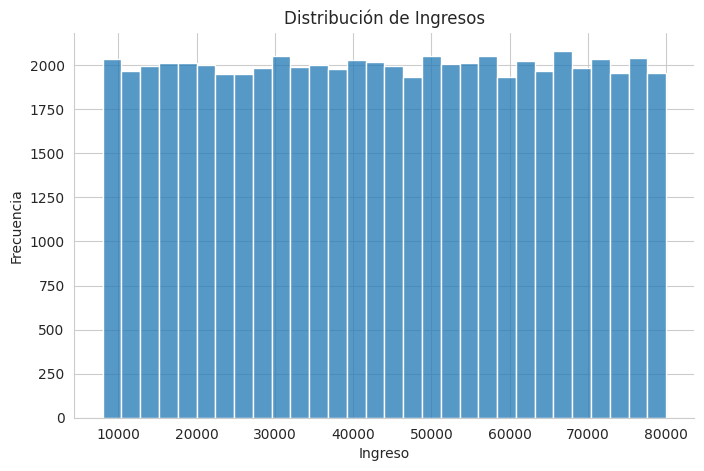

In [35]:
# Histograma
plt.figure(figsize=(8,5))
sns.histplot(df["Ingreso_Anual"], bins=30)
sns.despine()
plt.title("Distribución de Ingresos")
plt.xlabel("Ingreso")
plt.ylabel("Frecuencia")
plt.show()

# Los ingresos presentan una distribución relativamente uniforme.

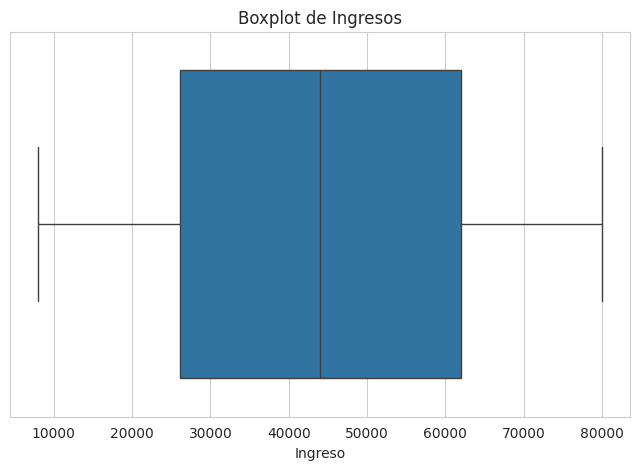

In [36]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Ingreso_Anual"])
plt.title("Boxplot de Ingresos")
plt.xlabel("Ingreso")
plt.show()


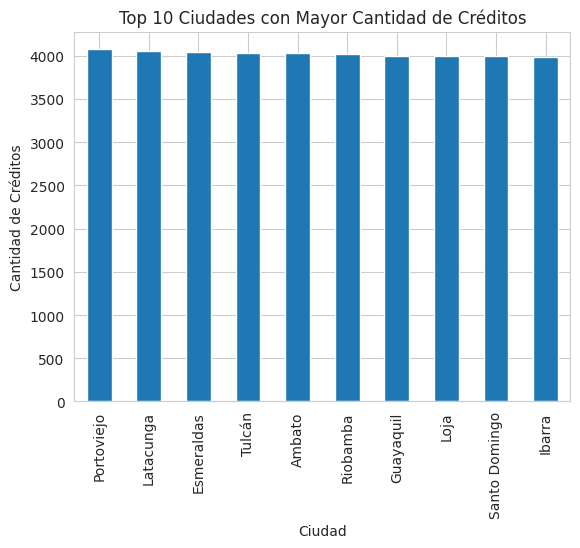

In [37]:
# Barras
df["Ciudad"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Ciudades con Mayor Cantidad de Créditos")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad de Créditos")
plt.show()

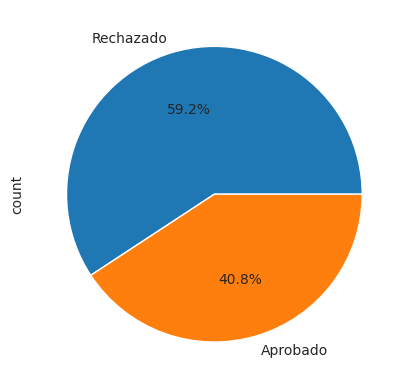

In [38]:
# Pastel
df["Estado_Credito"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.show()


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

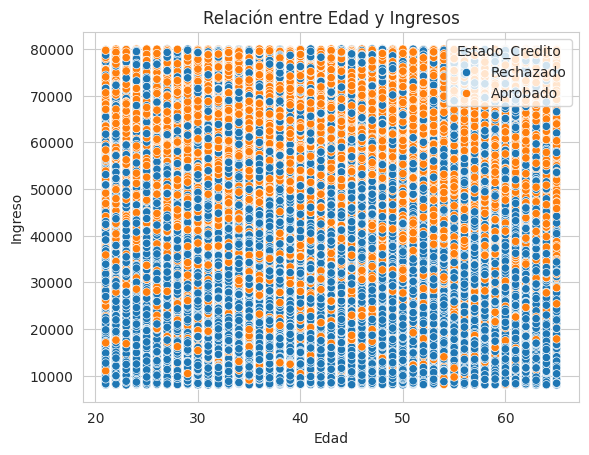

In [39]:
# Scatter
sns.scatterplot(
    data=df,
    x="Edad",
    y="Ingreso_Anual",
    hue="Estado_Credito"
)
plt.title("Relación entre Edad y Ingresos")
plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt

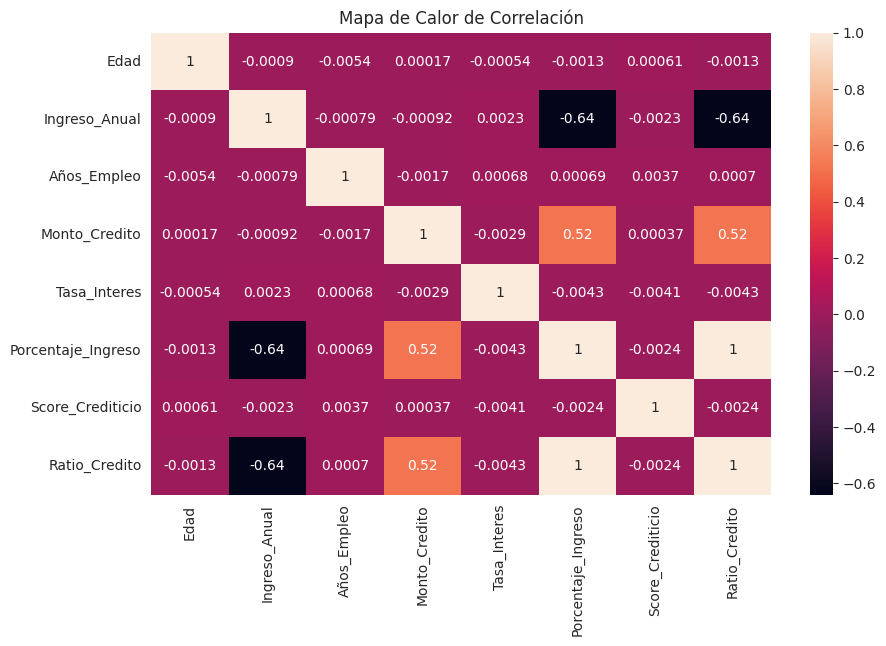

In [40]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.title("Mapa de Calor de Correlación")
plt.show()

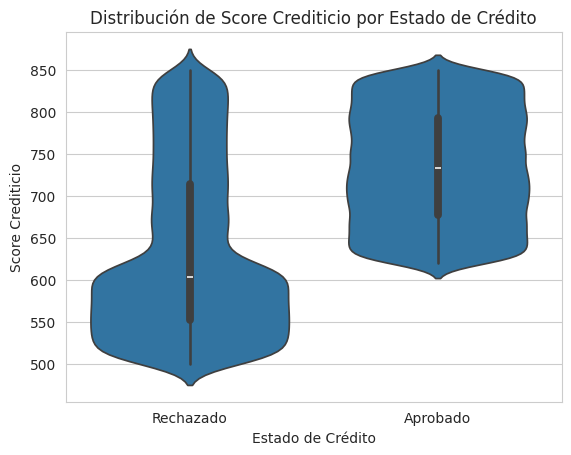

In [41]:
# Violin Plot
sns.violinplot(
    data=df,
    x="Estado_Credito",
    y="Score_Crediticio"
)
plt.title("Distribución de Score Crediticio por Estado de Crédito")
plt.xlabel("Estado de Crédito")
plt.ylabel("Score Crediticio")
plt.show()


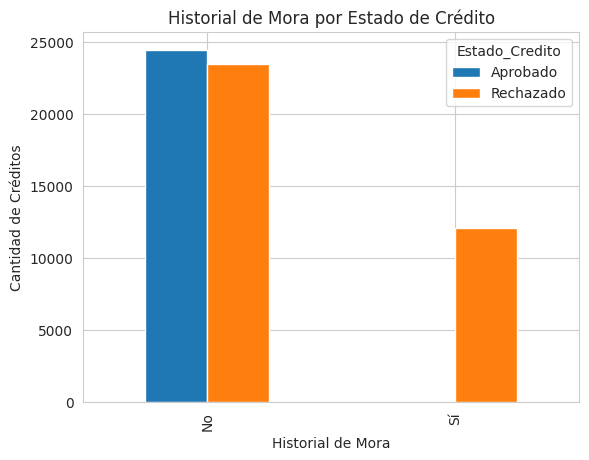

In [42]:
# Barras Agrupadas
pd.crosstab(
    df["Historial_Mora"],
    df["Estado_Credito"]
).plot(kind="bar")
plt.title("Historial de Mora por Estado de Crédito")
plt.xlabel("Historial de Mora")
plt.ylabel("Cantidad de Créditos")
plt.show()

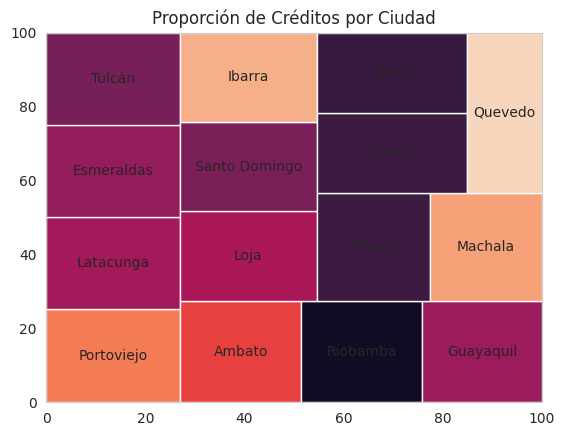

In [43]:
# Treemap
!pip install squarify
import squarify

ciudades = df["Ciudad"].value_counts()

squarify.plot(
    sizes=ciudades.values,
    label=ciudades.index
)
plt.title("Proporción de Créditos por Ciudad")
plt.show()

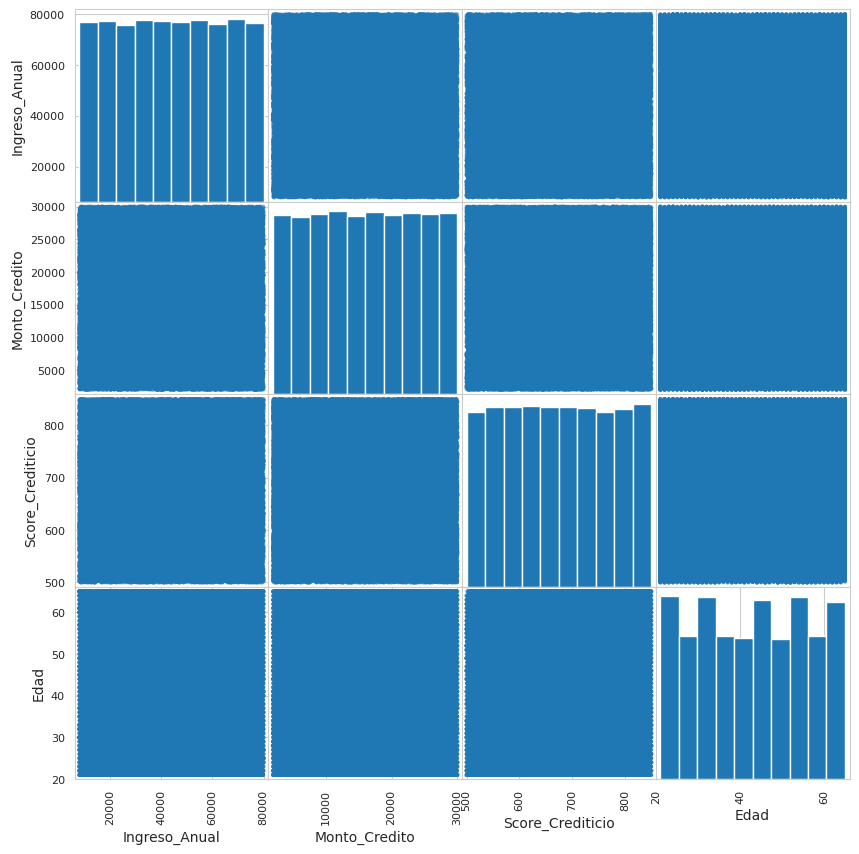

In [44]:
# Scatter Matrix
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[
        [
            "Ingreso_Anual",
            "Monto_Credito",
            "Score_Crediticio",
            "Edad"
        ]
    ],
    figsize=(10,10)
)

plt.show()

#11. MACHINE LEARNING

##Variable objetivo
Estado_Credito

Se busca predecir si un crédito será aprobado o rechazado.

In [45]:
# Codificación

df_ml = df.copy()

encoder = LabelEncoder()

for col in df_ml.select_dtypes(include="object"):
    df_ml[col] = encoder.fit_transform(df_ml[col])

In [46]:
# X e Y

X = df_ml.drop("Estado_Credito", axis=1)

y = df_ml["Estado_Credito"]


In [47]:
# División

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [48]:
# Entrenamiento
modelo = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [49]:
# Predicción
y_pred = modelo.predict(X_test)

#12. EVALUACIÓN

In [50]:
# Accuracy
accuracy_score(y_test, y_pred)

1.0

In [51]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4880
           1       1.00      1.00      1.00      7120

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



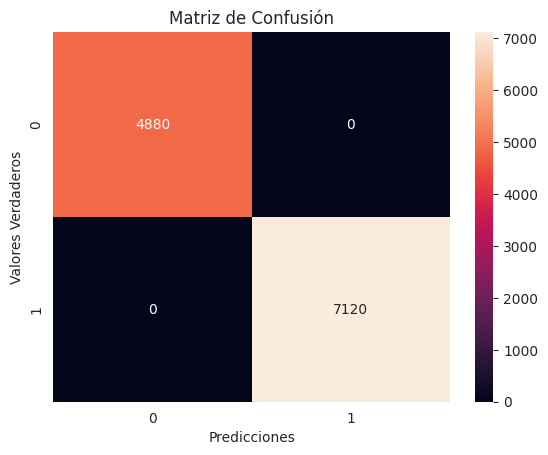

In [52]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Verdaderos")
plt.show()

#13. OPTIMIZACIÓN BÁSICA

In [53]:
parametros = {
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(),
    parametros,
    cv=5
)

grid.fit(X_train,y_train)

grid.best_params_

{'max_depth': 3, 'min_samples_split': 2}

In [54]:
from sklearn.metrics import accuracy_score

y_pred = grid.best_estimator_.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

# 14. CONCLUSIONES

1. El dataset permitió desarrollar un proceso completo de análisis de datos y Machine Learning.

2. El Score Crediticio fue una de las variables con mayor influencia en la aprobación de créditos.

3. Los clientes con historial de mora presentan una mayor probabilidad de rechazo.

4. El Árbol de Decisión logró identificar patrones relevantes para clasificar solicitudes de crédito.

5. El modelo puede servir como apoyo para la evaluación preliminar de riesgo crediticio.

# 15. RECOMENDACIONES

1. Incorporar variables históricas de pagos.
2. Añadir información temporal de comportamiento financiero.
3. Probar modelos Random Forest y XGBoost.
4. Realizar balanceo de clases si se detecta sesgo.
5. Implementar validación cruzada avanzada.